In [7]:
pip install pandas numpy scipy scikit-learn seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score)
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy import stats
df = pd.read_csv('Downloads/employee_performance.csv')
df.head(25)


,Employee_ID,Age,Gender,Department,Experience_Years,Hours_Worked_Per_Week,Training_Score,Job_Satisfaction,Projects_Completed,Performance
0,1,50,Female,Finance,25,58,70,5,10,Average
1,2,36,Female,Operations,7,51,57,3,4,Poor
2,3,29,Male,IT,4,44,95,9,8,Poor
3,4,42,Male,Finance,8,44,89,5,18,Average
4,5,40,Male,Sales,20,58,95,5,14,Average
5,6,44,Female,Finance,29,38,56,4,18,Average
6,7,32,Male,HR,10,54,72,4,14,Poor
7,8,32,Female,Finance,34,38,93,1,15,Average
8,9,45,Female,HR,26,56,81,7,4,Average
9,10,57,Male,Finance,3,41,60,9,13,Poor


In [9]:
print("\nShape of dataset:")
print(df.shape)

# Display column names
print("\nColumns:")
print(df.columns)

# Display data types
print("\nData Types:")
print(df.dtypes)


Shape of dataset:
(500, 10)

Columns:
Index(['Employee_ID', 'Age', 'Gender', 'Department', 'Experience_Years',
       'Hours_Worked_Per_Week', 'Training_Score', 'Job_Satisfaction',
       'Projects_Completed', 'Performance'],
      dtype='str')

Data Types:
Employee_ID              int64
Age                      int64
Gender                     str
Department                 str
Experience_Years         int64
Hours_Worked_Per_Week    int64
Training_Score           int64
Job_Satisfaction         int64
Projects_Completed       int64
Performance                str
dtype: object


In [10]:
#Q1(a) Identify missing values
print('Identifying missing values', df.isnull().sum())

Identifying missing values Employee_ID              0
Age                      0
Gender                   0
Department               0
Experience_Years         0
Hours_Worked_Per_Week    0
Training_Score           0
Job_Satisfaction         0
Projects_Completed       0
Performance              0
dtype: int64


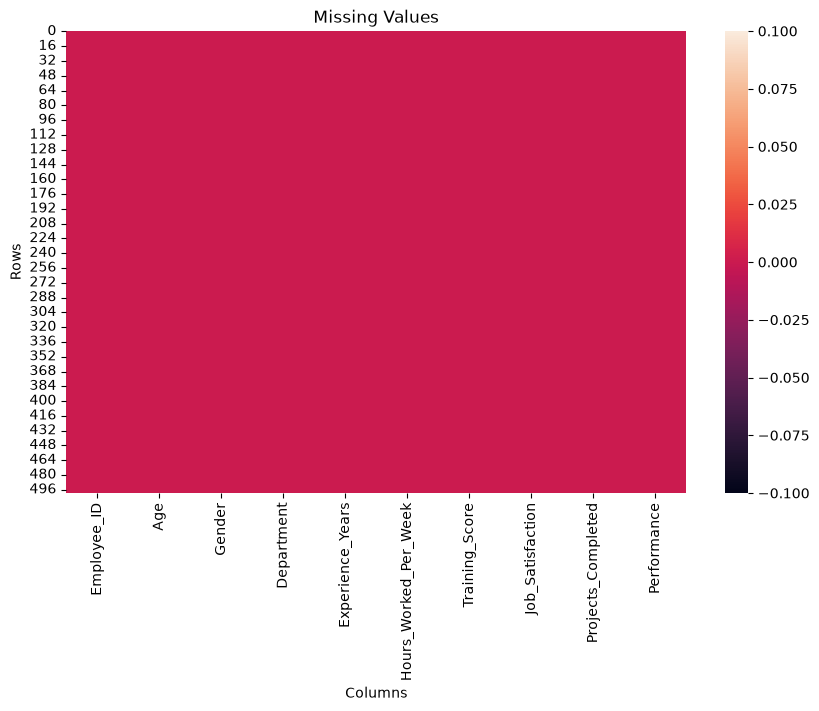

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), fmt='.2f')
plt.title("Missing Values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [12]:
#b. Identify duplicate records in the dataset. Display the number of duplicate records and remove/handle them appropriately.
print('Duplicate records',df.duplicated().any())
print('Duplicate records sum', df.duplicated().sum())
df = df.drop_duplicates()                                   # Remove duplicates andd store in df
print("Duplicates after removal:", df.duplicated().sum())  

Duplicate records False
Duplicate records sum 0
Duplicates after removal: 0


In [13]:
#identify null or nan Values from dataset
print('Nan or null values', df.isnull().sum())
# Remove rows containing NaN/Null values
df = df.dropna()
print("\nNaN/Null values after handling:")
print(df.isnull().sum())

Nan or null values Employee_ID              0
Age                      0
Gender                   0
Department               0
Experience_Years         0
Hours_Worked_Per_Week    0
Training_Score           0
Job_Satisfaction         0
Projects_Completed       0
Performance              0
dtype: int64

NaN/Null values after handling:
Employee_ID              0
Age                      0
Gender                   0
Department               0
Experience_Years         0
Hours_Worked_Per_Week    0
Training_Score           0
Job_Satisfaction         0
Projects_Completed       0
Performance              0
dtype: int64


In [14]:
# Identify NaN/Null values
print("Before median imputation:")
print(df.isnull().sum())

# Select numerical columns
numeric_cols = df.select_dtypes(include='number').columns

# Replace missing numerical values with median
df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

# Check after imputation
print("\nAfter median imputation:")
print(df.isnull().sum())

Before median imputation:
Employee_ID              0
Age                      0
Gender                   0
Department               0
Experience_Years         0
Hours_Worked_Per_Week    0
Training_Score           0
Job_Satisfaction         0
Projects_Completed       0
Performance              0
dtype: int64

After median imputation:
Employee_ID              0
Age                      0
Gender                   0
Department               0
Experience_Years         0
Hours_Worked_Per_Week    0
Training_Score           0
Job_Satisfaction         0
Projects_Completed       0
Performance              0
dtype: int64


In [15]:
print((df == 0).any())

Employee_ID              False
Age                      False
Gender                   False
Department               False
Experience_Years         False
Hours_Worked_Per_Week    False
Training_Score           False
Job_Satisfaction         False
Projects_Completed       False
Performance              False
dtype: bool


In [ ]:
#Median imputation code 
print((df == 0).any())                   #to check which column contains 0 values
cols_with_zeros = ['x','y','z']          # store in names in array and assign it to variable
df[cols_with_zeros]= df[cols_with_zeros].replace(0,np.nan)  #so we need to replace 0 with median so df[colswithzero] , .replace ,np.nan
for col in cols_with_zeros:
    df.fillna({col:df[col].median()},inplace=True)   #using fillna we use col variable for every col in df replace with median 
print(df.isnull().sum())
print(df.head(10))

In [17]:
#Q1(d) Identify Numerical and Categorical Columns
numerical_cols = df.select_dtypes(include='number').columns
print('Numerical Columns',numeric_cols)
categorical_cols = df.select_dtypes(include='str').columns
print('Categorical Columns',categorical_cols)

Numerical Columns Index(['Employee_ID', 'Age', 'Experience_Years', 'Hours_Worked_Per_Week',
       'Training_Score', 'Job_Satisfaction', 'Projects_Completed'],
      dtype='str')
Categorical Columns Index(['Gender', 'Department', 'Performance'], dtype='str')


In [18]:
# Split the dataset into Training (80%) and Testing (20%) sets.

from sklearn.model_selection import train_test_split                        #import the lib first
X = df.drop('Performance',axis=1)                                           #remove from features using drop and axis
y = df['Performance']                                                       #storing it into y
X_train , X_test , y_train , y_test = train_test_split(
    X ,y , test_size=0.20 , random_state=42)
print('Training data', X_train.shape)                                       #shape is not a function
print('Testing data', X_test.shape)



Training data (400, 9)
Testing data (100, 9)


In [23]:
df.describe()

,Employee_ID,Age,Experience_Years,Hours_Worked_Per_Week,Training_Score,Job_Satisfaction,Projects_Completed
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,250.500000,41.322000,17.640000,46.896000,74.54800,5.248000,10.146000
std,144.481833,11.051633,9.876715,7.329436,14.29645,2.817512,5.451617
min,1.000000,22.000000,1.000000,35.000000,50.00000,1.000000,1.000000
25%,125.750000,32.000000,9.000000,40.750000,63.00000,3.000000,5.000000
50%,250.500000,43.000000,17.000000,47.000000,74.00000,5.000000,10.000000
75%,375.250000,51.000000,26.000000,54.000000,87.00000,8.000000,15.000000
max,500.000000,59.000000,34.000000,59.000000,99.00000,10.000000,19.000000


<Axes: ylabel='Frequency'>

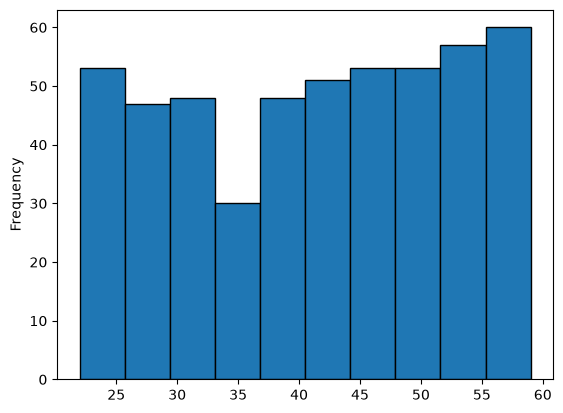

In [24]:
# Display statistical summary of numerical columns

df['Age'].plot(kind='hist' ,edgecolor='black')

Text(0, 0.5, 'Number of Employees')

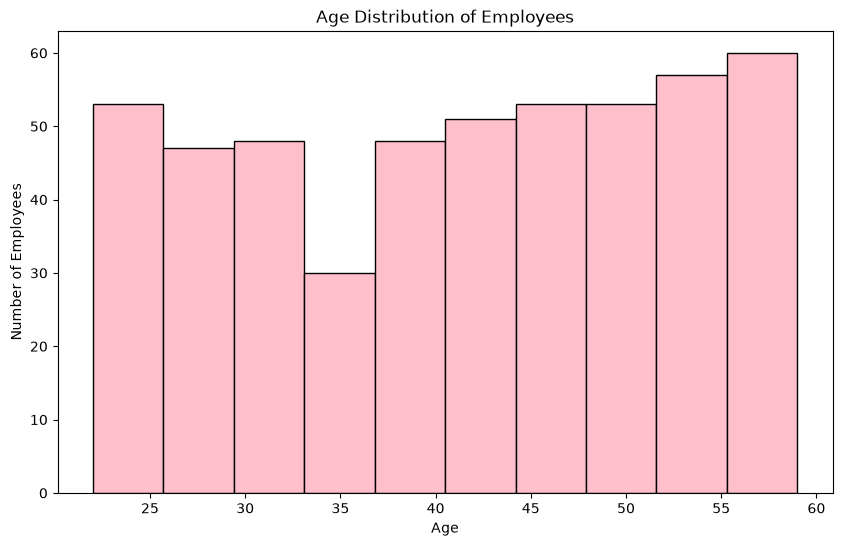

In [25]:
# Analyze the distribution of employees based on Age using a Histogram.

plt.figure(figsize=(10,6))             #default X-axis → Age values / Age intervals      Y-axis → Number of observations (frequency)
plt.hist(df['Age'],bins=10 , edgecolor='black' ,color='pink' )  #bins necessary 
plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

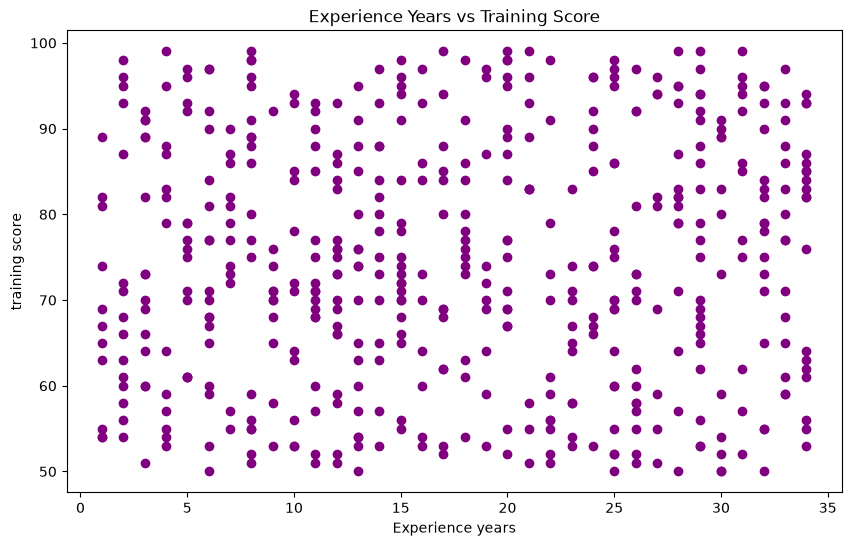

In [26]:
# Analyze the relationship between Experience_Years and Training_Score using a Scatter Plot.

plt.figure(figsize=(10,6))
plt.scatter(df['Experience_Years'],df['Training_Score'],color='purple')
plt.title("Experience Years vs Training Score")
plt.xlabel('Experience years')
plt.ylabel('training score')
plt.show()

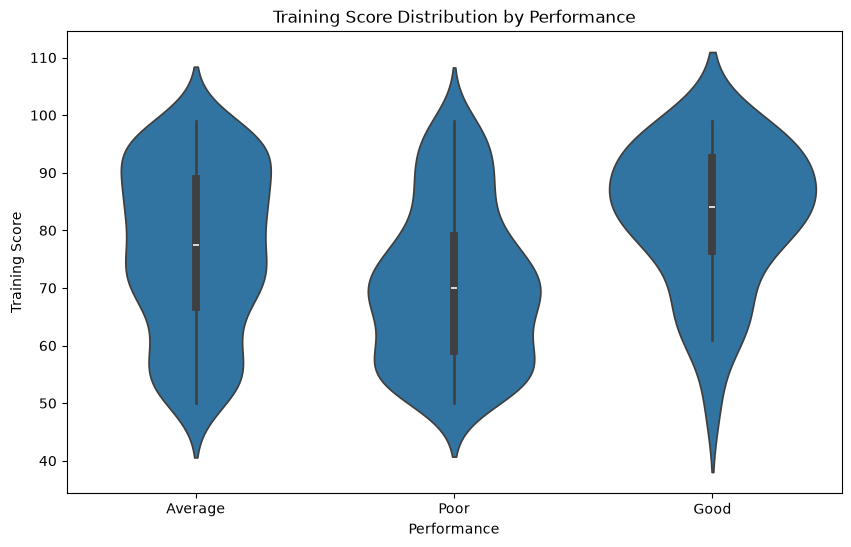

In [27]:
# Analyze the distribution of Training_Score for different Performance categories using a Violin Plot.
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='Performance',
    y='Training_Score'
)

plt.title("Training Score Distribution by Performance")
plt.xlabel("Performance")
plt.ylabel("Training Score")

plt.show()

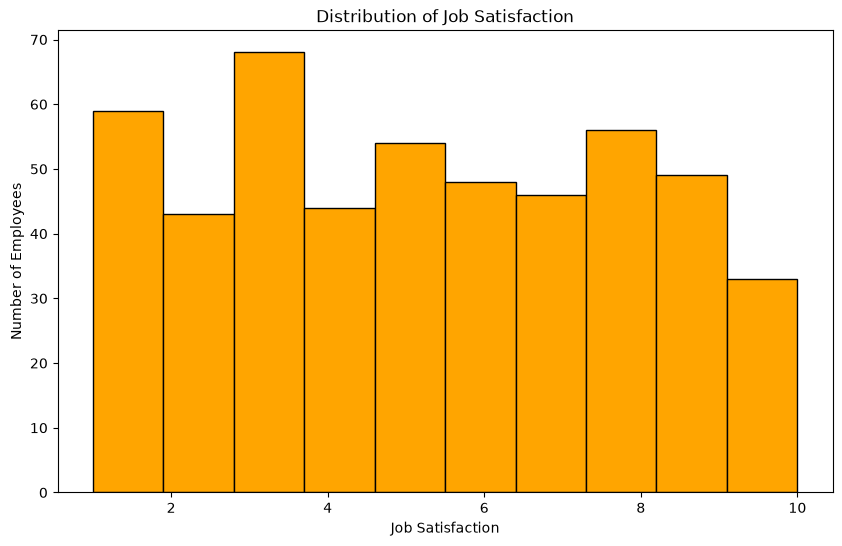

In [28]:
#Analyze the distribution of Job_Satisfaction using a suitable visualization and explain the result.
plt.figure(figsize=(10, 6))

plt.hist(
    df['Job_Satisfaction'],
    bins=10,
    edgecolor='black' , color='orange'
)

plt.title("Distribution of Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Employees")

plt.show()

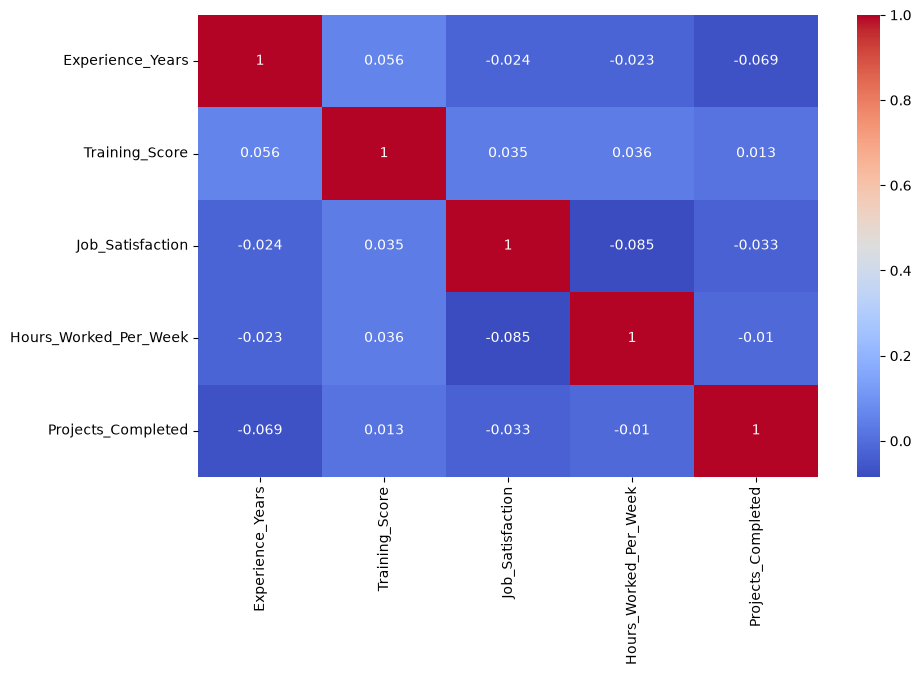

In [29]:
# a. Generate a Correlation Heatmap for:
# Experience_Years
# Training_Score
# Job_Satisfaction
# Hours_Worked_Per_Week
# Projects_Completed
# Identify which variables have the strongest correlation.

cols = ['Experience_Years','Training_Score','Job_Satisfaction','Hours_Worked_Per_Week','Projects_Completed']
correlation = df[cols].corr()   #using corr() for correlation and storing it into variable
plt.figure(figsize=(10,6))
sns.heatmap(correlation,cmap='coolwarm',annot= True)
plt.show()

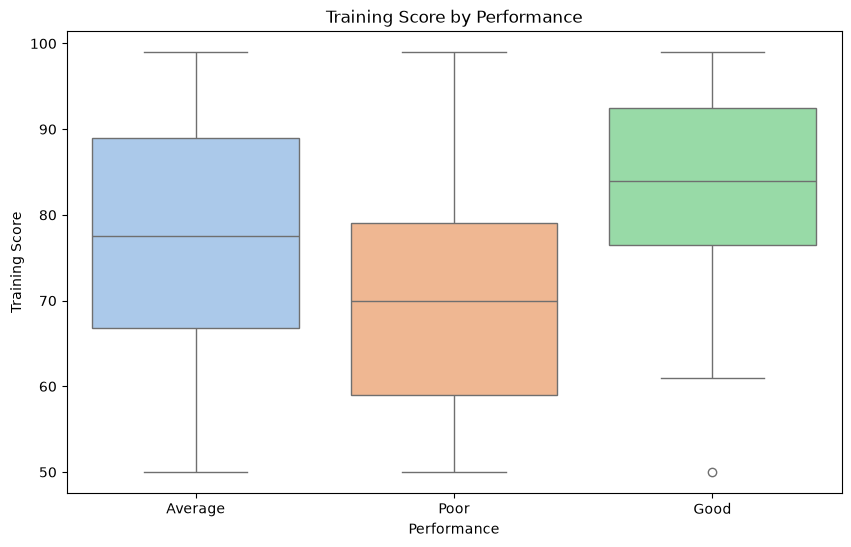

In [30]:
#Generate a Box Plot of Training_Score grouped by Performance and identify possible outliers.
plt.figure(figsize=(10,6))
sns.boxplot(data=df , x='Performance', y='Training_Score' , palette='pastel',hue='Performance' , legend=False)
plt.title("Training Score by Performance")
plt.xlabel("Performance")
plt.ylabel("Training Score")
plt.show()

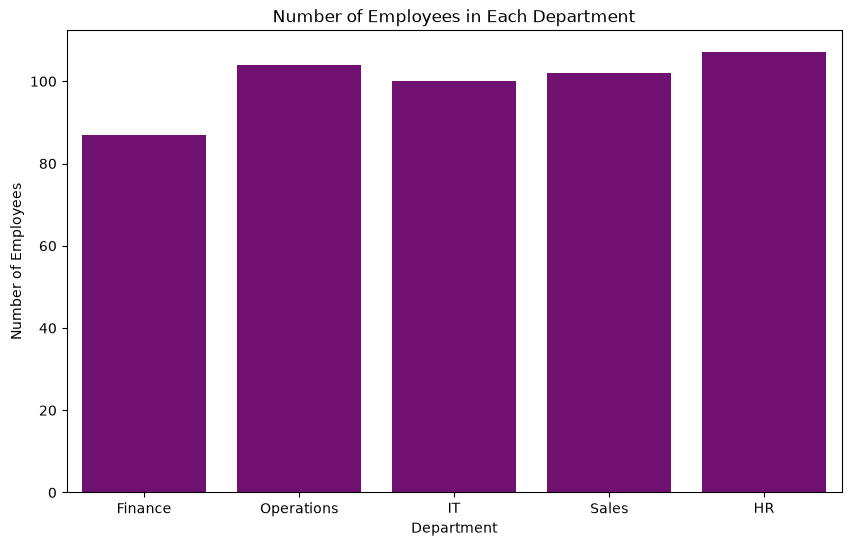

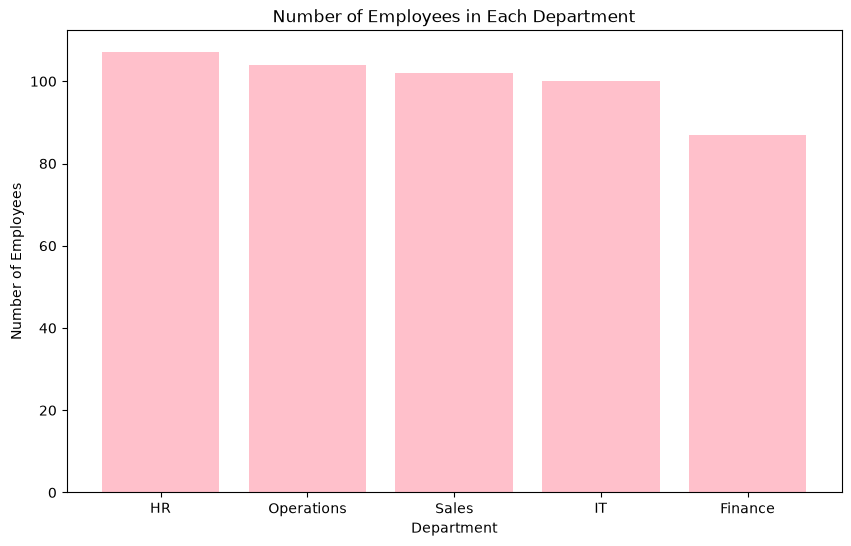

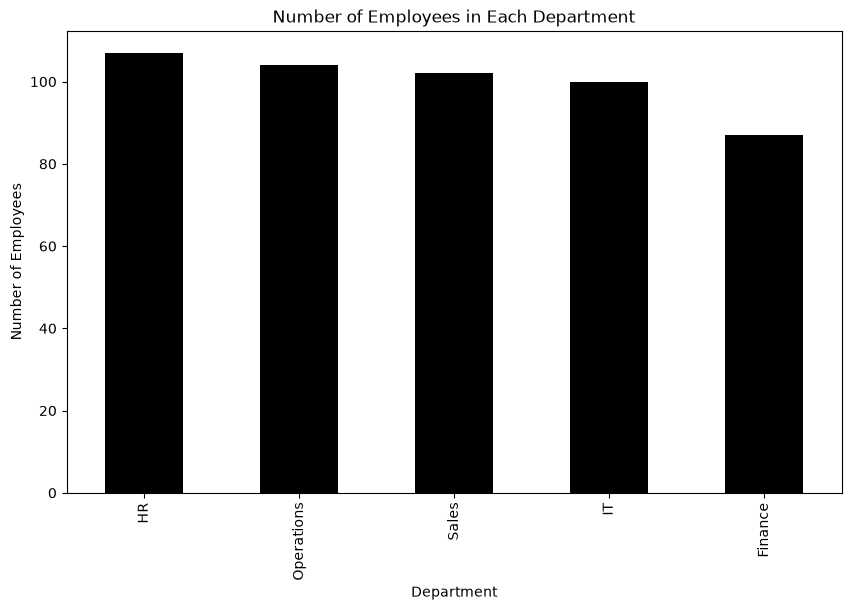

In [31]:
#Generate a Bar Chart showing the number of employees in each Department.
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='Department' ,  color='purple'
)

plt.title("Number of Employees in Each Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.show()

#option2 using plt
import matplotlib.pyplot as plt

department_counts = df['Department'].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    department_counts.index,
    department_counts.values , color='pink'
)

plt.title("Number of Employees in Each Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.show()

#option3 using plot 
department_counts = df['Department'].value_counts()
plt.figure(figsize=(10,6))

department_counts.plot(kind='bar' , color='black')

plt.title("Number of Employees in Each Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.show()

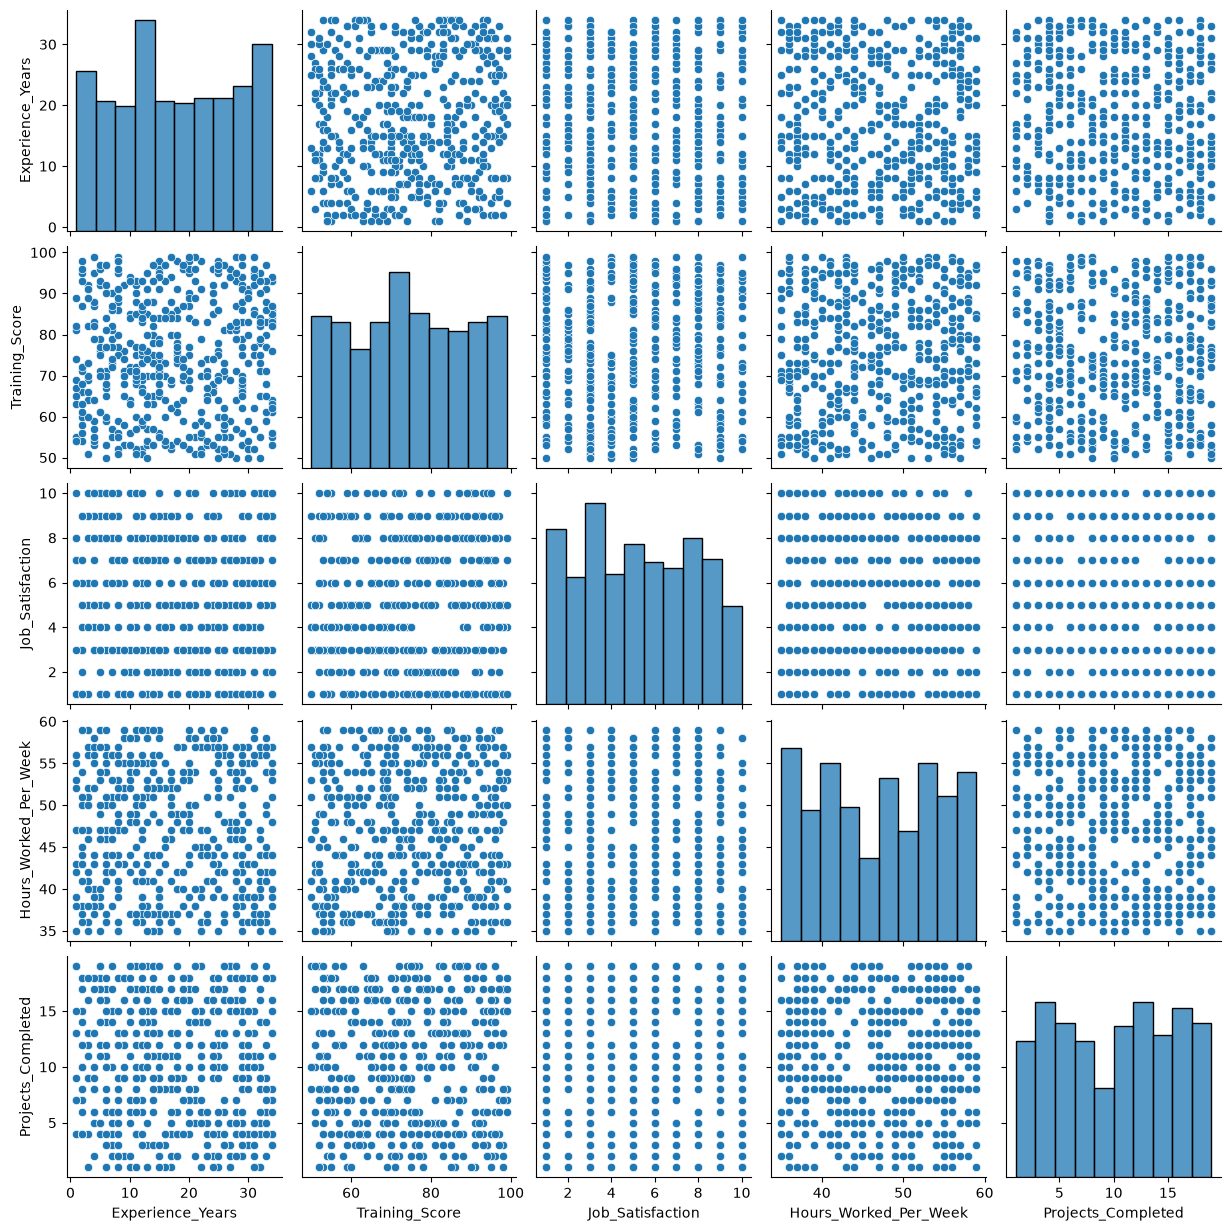

In [32]:
#Generate a Pair Plot for selected numerical features and analyze the relationships between them.
cols = [
    'Experience_Years',
    'Training_Score',
    'Job_Satisfaction',
    'Hours_Worked_Per_Week',
    'Projects_Completed'
]

sns.pairplot(df[cols])

plt.show()

Performance  Average  Good  Poor
Department                      
Finance           40     5    42
HR                57     6    44
IT                46    11    43
Operations        51     9    44
Sales             62     4    36


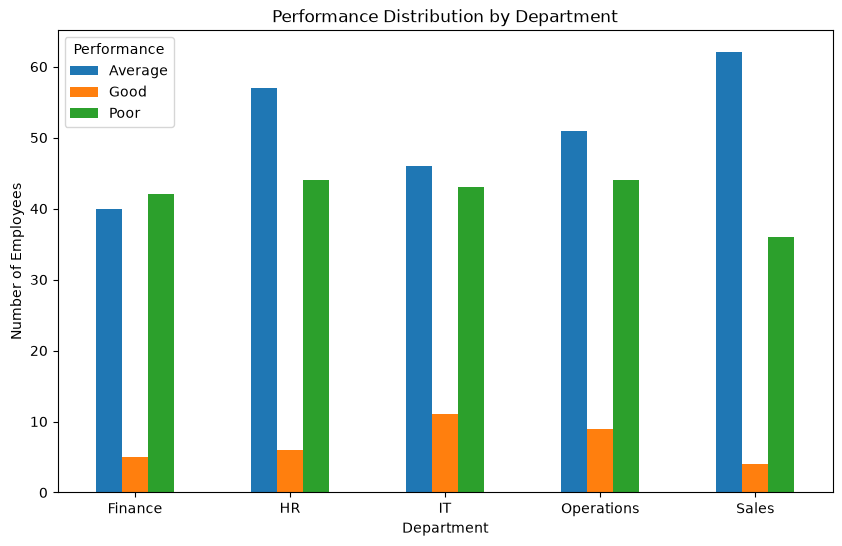

In [33]:
# Q2(b) Performance distribution by department

# Create frequency table
performance_department = pd.crosstab(
    df['Department'],
    df['Performance']
)

print(performance_department)

# Create bar chart
performance_department.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Performance Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.legend(title="Performance")

plt.show()

In [34]:
#a. Create an AgeGroup column using the following categories:
# Young       → Age < 30
# Middle      → Age 30–40
# Senior      → Age > 40

def age_group(age):
    if age < 30:
        return 'Young'
    elif age <= 40:
        return 'Middle'
    else:
        return 'Senior'


df['AgeGroup'] = df['Age'].apply(age_group)

print(df[['Age', 'AgeGroup']].head(10))

   Age AgeGroup
0   50   Senior
1   36   Middle
2   29    Young
3   42   Senior
4   40   Middle
5   44   Senior
6   32   Middle
7   32   Middle
8   45   Senior
9   57   Senior


In [35]:
#b. Create an Experience_Level column:
# Beginner    → Experience < 3
# Intermediate → Experience 3–7
def exp_level(exp):
    if exp<5:
        return 'Begineer'
    elif exp>=4 and exp<=7:
        return 'Intermediate'
    else:
        return 'Senior'
df['Experience_Level']=df['Experience_Years'].apply(exp_level)
print(df[['Experience_Years','Experience_Level']].head(10))

   Experience_Years Experience_Level
0                25           Senior
1                 7     Intermediate
2                 4         Begineer
3                 8           Senior
4                20           Senior
5                29           Senior
6                10           Senior
7                34           Senior
8                26           Senior
9                 3         Begineer


In [36]:
#Create a Workload_Level column based on Hours_Worked_Per_Week:
# Low       → < 35
# Normal    → 35–45
# High      → > 45
def workload_level(hrs):
    if hrs < 35:
        return 'Low'
    elif hrs>=35 and hrs<=45:
        return 'Normal'
    else:
        return 'High'
df['Workload_Level']=df['Hours_Worked_Per_Week'].apply(workload_level)
print(df[['Workload_Level','Hours_Worked_Per_Week']].head(15))


   Workload_Level  Hours_Worked_Per_Week
0            High                     58
1            High                     51
2          Normal                     44
3          Normal                     44
4            High                     58
5          Normal                     38
6            High                     54
7          Normal                     38
8            High                     56
9          Normal                     41
10           High                     56
11         Normal                     35
12           High                     46
13           High                     58
14           High                     47


In [37]:
print(df[['AgeGroup','Workload_Level','Experience_Level']])

    AgeGroup Workload_Level Experience_Level
0     Senior           High           Senior
1     Middle           High     Intermediate
2      Young         Normal         Begineer
3     Senior         Normal           Senior
4     Middle           High           Senior
..       ...            ...              ...
495   Senior         Normal           Senior
496    Young           High           Senior
497   Middle           High           Senior
498   Middle           High           Senior
499   Senior           High     Intermediate

[500 rows x 3 columns]


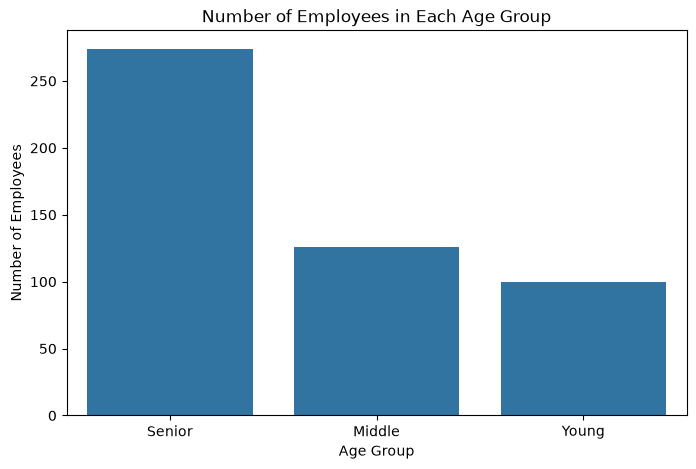

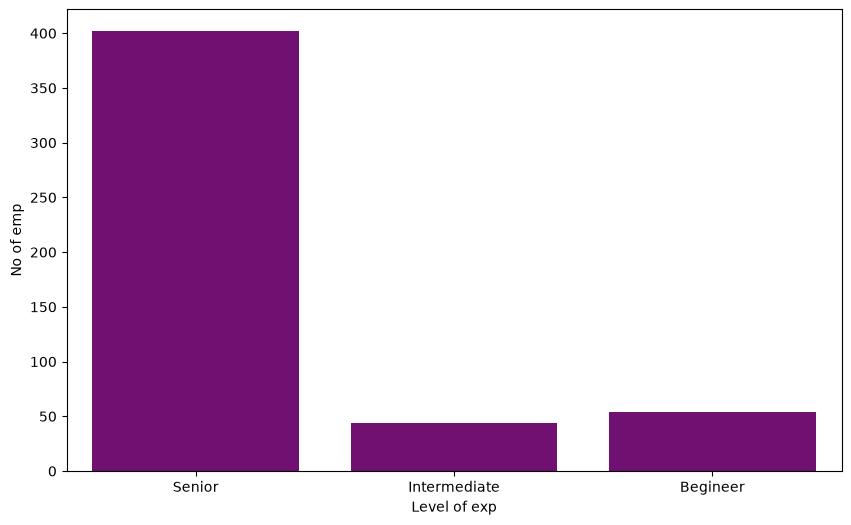

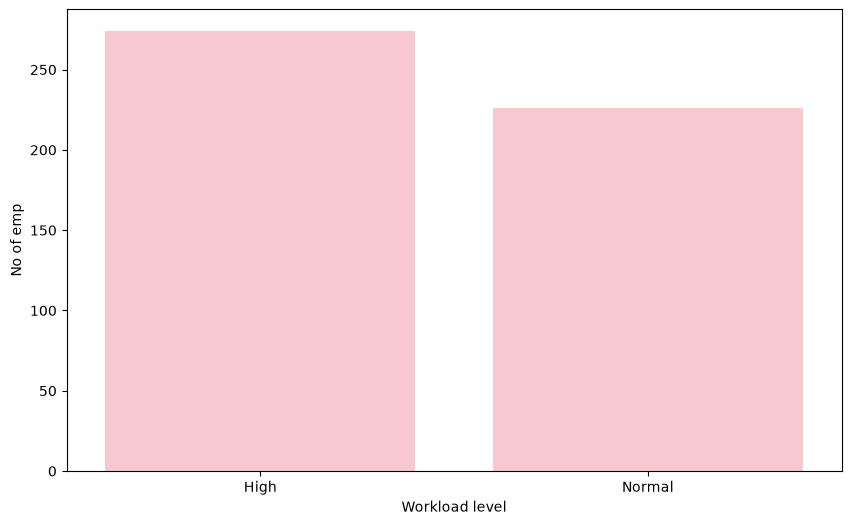

In [38]:

# Visualize AgeGroup
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='AgeGroup')

plt.title("Number of Employees in Each Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")

plt.show()

#visualize Experience level
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Experience_Level',color='purple')
plt.xlabel('Level of exp')
plt.ylabel('No of emp')
plt.show()

#visualize workload_level
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Workload_Level',color='pink')
plt.xlabel('Workload level')
plt.ylabel('No of emp')
plt.show()




In [39]:
sns.countplot??

Signature:
sns.countplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    order=None,
    hue_order=None,
    orient=None,
    color=None,
    palette=None,
    saturation=0.75,
    fill=True,
    hue_norm=None,
    stat='count',
    width=0.8,
    dodge='auto',
    gap=0,
    log_scale=None,
    native_scale=False,
    formatter=None,
    legend='auto',
    ax=None,
    **kwargs,
)
Docstring:
Show the counts of observations in each categorical bin using bars.

A count plot can be thought of as a histogram across a categorical, instead
of quantitative, variable. The basic API and options are identical to those
for :func:`barplot`, so you can compare counts across nested variables.

Note that :func:`histplot` function offers similar functionality with additional
features (e.g. bar stacking), although its default behavior is somewhat different.

See the :ref:`tutorial <categorical_tutorial>` for more information.

.. note::
    By default, this function treats one of the 

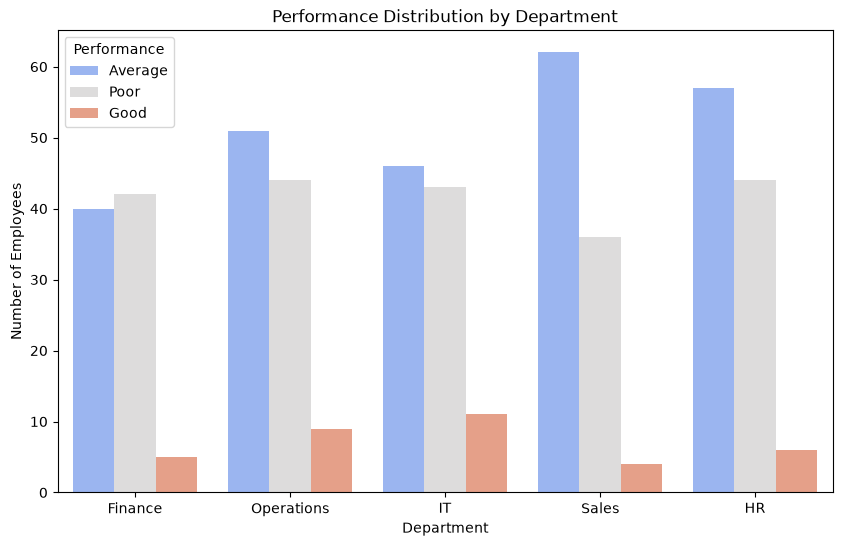

In [44]:
#Generate a Bar Chart showing performance distribution by department

plt.figure(figsize=(10, 6))

sns.countplot(                 #for barchart use countplot 
    data=df,                   #params data=df , x='department' , hue='performance' 
    x='Department',         
    hue='Performance' , palette='coolwarm'
)

plt.title("Performance Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.show()

Department
Finance       1.111111
HR            1.095238
IT            1.192982
Operations    1.150000
Sales         1.060606
Name: Performance_Score, dtype: float64


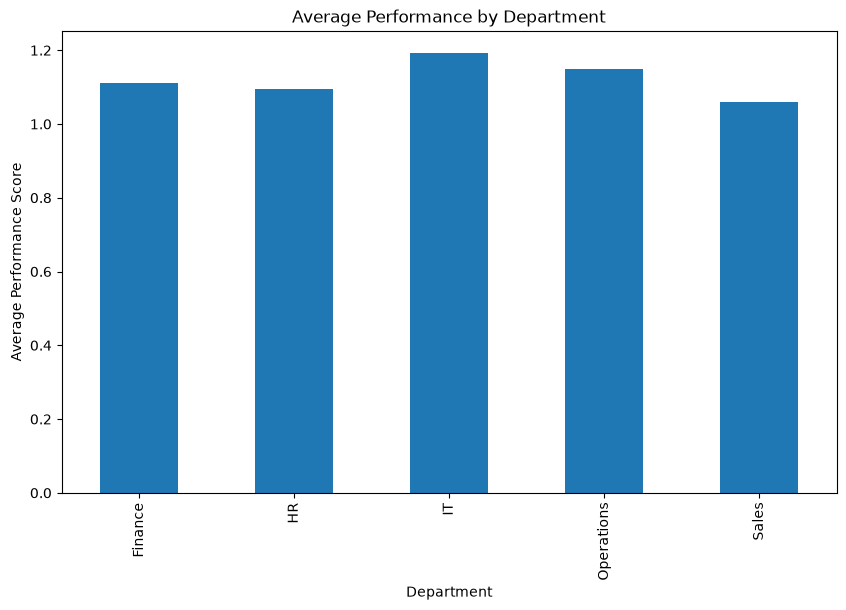

In [45]:
# Convert Performance into numerical values
performance_map = {
    'Low': 0,
    'Average': 1,
    'Good': 2
}

df['Performance_Score'] = df['Performance'].map(performance_map)  #map() method for mapping 
#Group employees by department → select their performance scores → calculate the average performance score for each department 
#→ store the result in performance_department
# Calculate average performance for each department
performance_department = df.groupby('Department')['Performance_Score'].mean()

print(performance_department)

# Bar chart
plt.figure(figsize=(10, 6))

performance_department.plot(kind='bar')

plt.title("Average Performance by Department")
plt.xlabel("Department")
plt.ylabel("Average Performance Score")

plt.show()

Performance_Group
Low Performers     465
High Performers     35
Name: count, dtype: int64


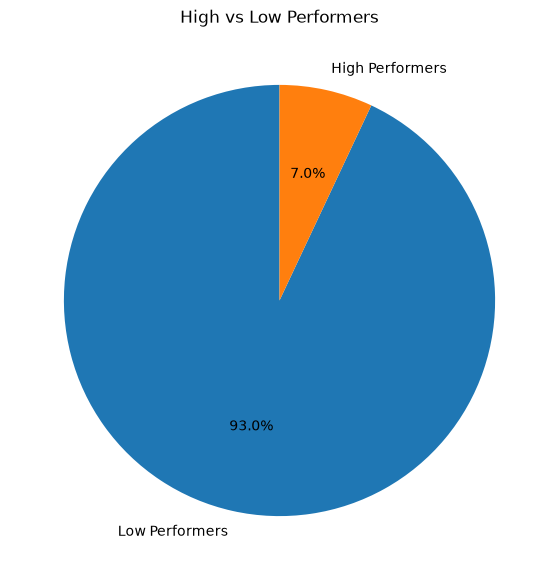

In [46]:
# Create High and Low performer categories
df['Performance_Group'] = df['Performance'].apply(
    lambda x: 'High Performers' if x == 'Good' else 'Low Performers'
)

# Count each group
performance_counts = df['Performance_Group'].value_counts()

print(performance_counts)

# Pie chart
plt.figure(figsize=(7, 7))
plt.pie(
    performance_counts,
    labels=performance_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("High vs Low Performers")
plt.show()


#option 2 using custom func
def perf_grp(value):
    if value=='Good':
        return 'High Performer'
    else:
        return 'Low Performer'
df['Performer_Group']=df['Performance'].apply(perf_grp)  
performance_count = df['Performer_Group'].value_counts()
labels= performance_count.index
print('performance_count',performance_count)
print('labels',labels)
plt.figure(figsize=(10,6))
plt.pie(performance_counts , labels=labels , autopct='%1.1f%%')
plt.show()

Training counts Training_Group
Medium    214
High      186
Low       100
Name: count, dtype: int64


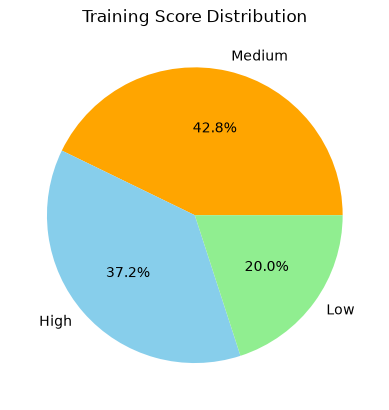

In [59]:
# Create training score groups
def training_group(score):   
    if score < 60:
        return 'Low'
    elif score <= 80:
        return 'Medium'
    else:
        return 'High'

df['Training_Group'] = df['Training_Score'].apply(training_group)  #store in custom col and use .apply() 

# Count each group
training_counts = df['Training_Group'].value_counts()  #count 
labels=training_counts.index
print('Training counts', training_counts)
# Pie chart
plt.pie(training_counts, labels=labels, autopct='%1.1f%%' , colors=['orange', 'skyblue', 'lightgreen'])

plt.title("Training Score Distribution")
plt.show()

performance_count Performer_Group
Low Performer     465
High Performer     35
Name: count, dtype: int64
labels Index(['Low Performer', 'High Performer'], dtype='str', name='Performer_Group')


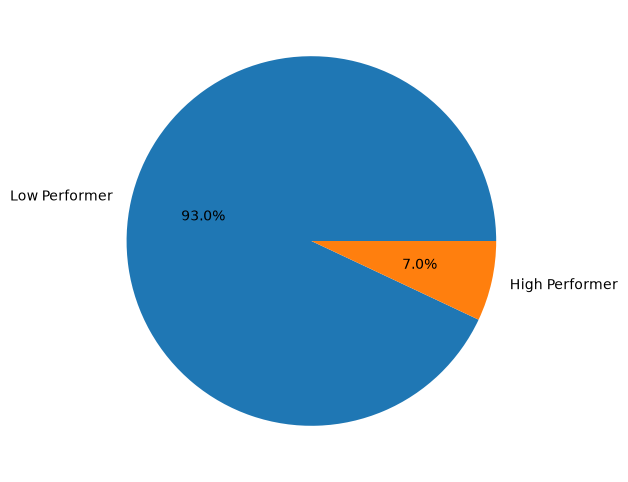

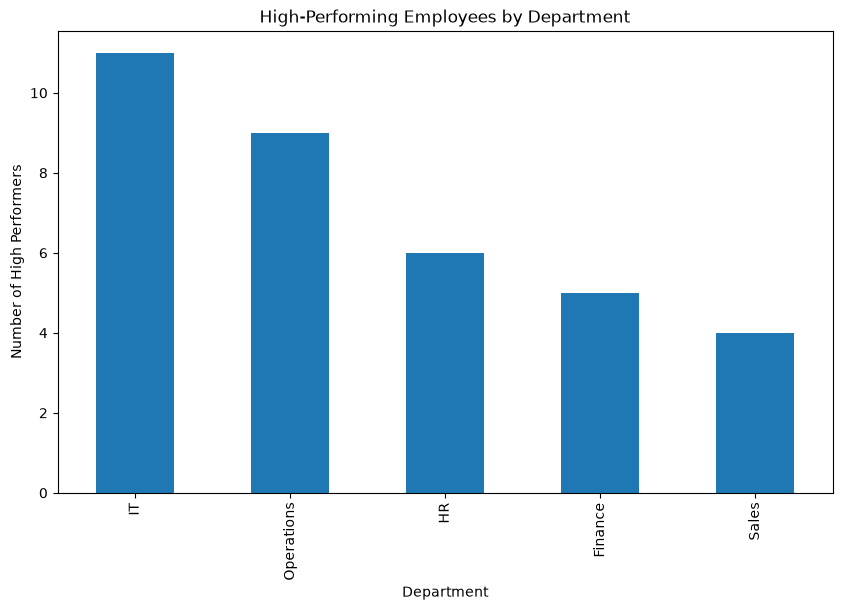

In [62]:
#Identify which department has the highest number of high-performing employees.
high_performers = df[df['Performance'] == 'Good']
department_counts = high_performers['Department'].value_counts()
plt.figure(figsize=(10, 6))
department_counts.plot(kind='bar')

plt.title("High-Performing Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of High Performers")

plt.show()

In [63]:
performance_map = {
    'Low': 0,
    'Average': 1,
    'Good': 2
}

df['Performance_Score'] = df['Performance'].map(performance_map)

print(df[['Experience_Years', 'Training_Score', 'Performance_Score']].corr())


                   Experience_Years  Training_Score  Performance_Score
Experience_Years           1.000000        0.056055           0.335511
Training_Score             0.056055        1.000000           0.130563
Performance_Score          0.335511        0.130563           1.000000


Number of outliers in each column:
Age                      0
Experience_Years         0
Training_Score           0
Hours_Worked_Per_Week    0
dtype: int64


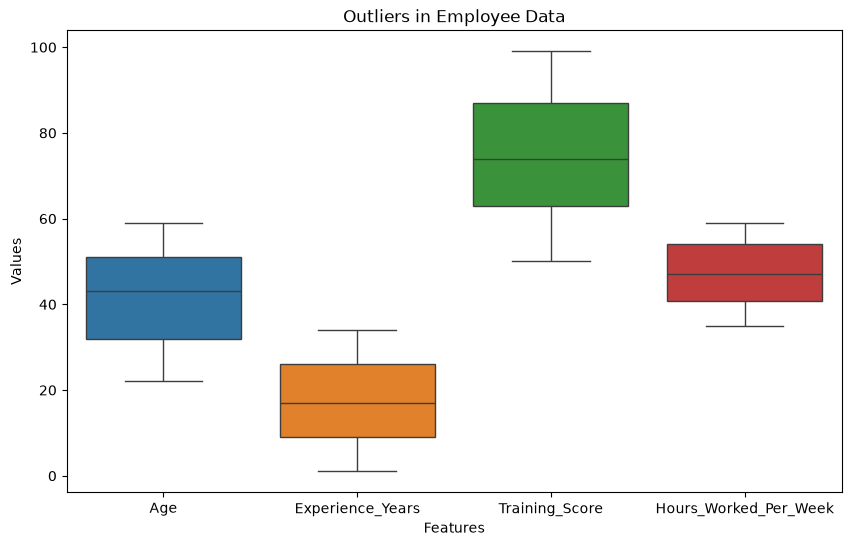

In [74]:
#a. Detect outliers in Age, Experience_Years, Training_Score, and Hours_Worked_Per_Week using the IQR method.
columns = ['Age','Experience_Years','Training_Score','Hours_Worked_Per_Week']  #1. Select the required columns
Q1=df[columns].quantile(0.25)
Q3=df[columns].quantile(0.75)
IQR=Q3-Q1
lower_limit= Q1-1.5*IQR
upper_limit = Q3 + 1.5 * IQR
outliers = (df[columns]<lower_limit) | (df[columns]>upper_limit)
print("Number of outliers in each column:")
print(outliers.sum())
# Visualize the outliers using Box Plots.
plt.figure(figsize=(10,6))
sns.boxplot(data=df[columns])
plt.title("Outliers in Employee Data")
plt.xlabel("Features")
plt.ylabel("Values")


plt.show()

Outliers handled successfully.


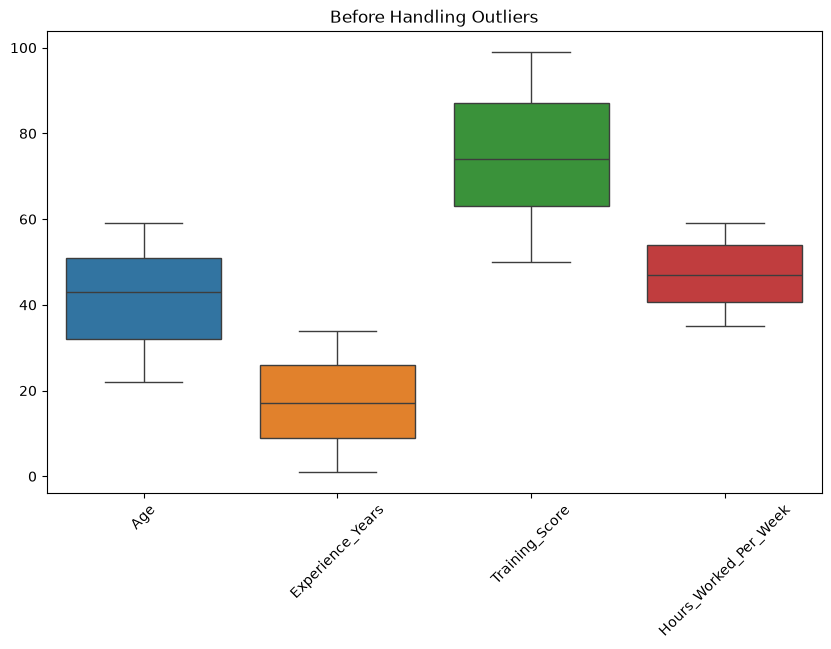

In [76]:
columns = [
    'Age',
    'Experience_Years',
    'Training_Score',
    'Hours_Worked_Per_Week'
]

Q1 = df[columns].quantile(0.25)
Q3 = df[columns].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Handle outliers by capping
for col in columns:
    df[col] = df[col].clip(lower=lower_limit[col] , upper=upper_limit[col]) #using clip() function

print("Outliers handled successfully.")
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[columns])

plt.title("Before Handling Outliers")
plt.xticks(rotation=45)
plt.show()

Accuracy: 95.0 %


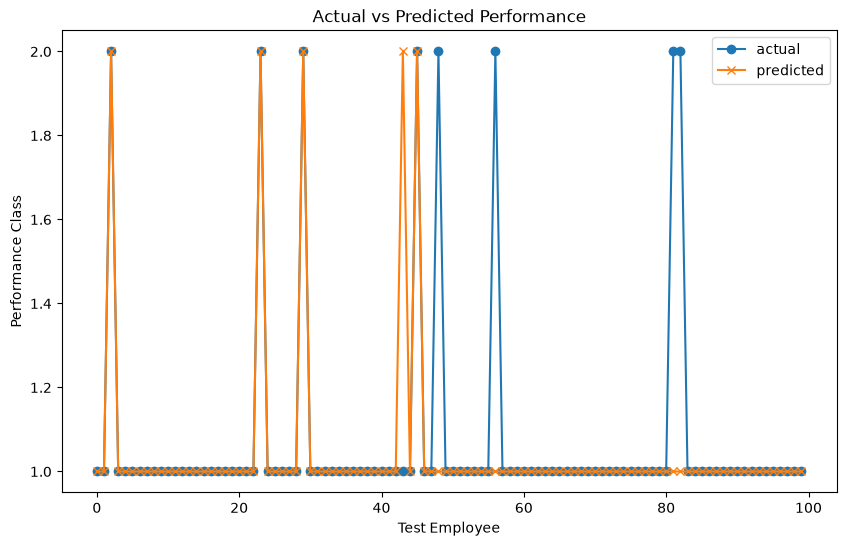

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


perf_map={'Poor':1 , 'Average':1, 'Good':2}
df['perf_num']=df['Performance'].map(perf_map)
features=['Age','Experience_Years','Hours_Worked_Per_Week', 'Training_Score','Job_Satisfaction','Projects_Completed']
X=df[features]
y=df['perf_num']
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.20,random_state=42)
scaler= StandardScaler()
x_scaled_train = scaler.fit_transform(X_train)
x_scaled_test = scaler.transform(X_test)
model = SVC(kernel='linear')
model.fit(X_train_scaled,y_train)
y_predic = model.predict(x_scaled_test)
accuracy=accuracy_score(y_test, y_predic)
print('Accuracy:' ,round(accuracy*100,2),"%")
plt.figure(figsize=(10, 6))
plt.plot(y_test.values , label='actual' , marker='o')
plt.plot(y_predic , label='predicted' , marker='x')
plt.title("Actual vs Predicted Performance")
plt.xlabel("Test Employee")
plt.ylabel("Performance Class")
plt.legend()
plt.show()

In [78]:
print(df['Performance'].unique())

<StringArray>
['Average', 'Poor', 'Good']
Length: 3, dtype: str


In [79]:
print(df['Performance_Num'].isnull().sum())

209


Accuracy: 93.0 %


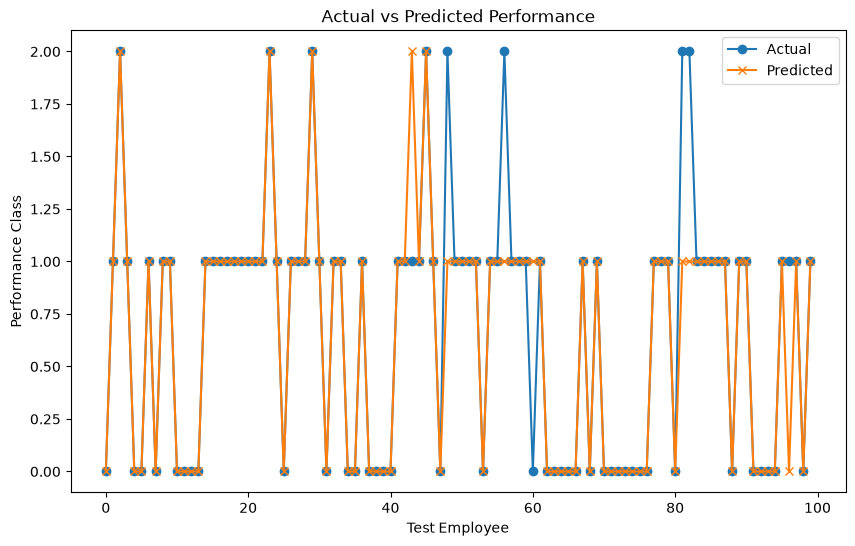

In [95]:
# 1. Encode Performance
performance_map = {
    'Poor': 0,
    'Average': 1,
    'Good': 2
}

df['Performance_Num'] = df['Performance'].map(performance_map) 

# 2. Select appropriate features
features = [
    'Age',
    'Experience_Years',
    'Hours_Worked_Per_Week',
    'Training_Score',
    'Job_Satisfaction',
    'Projects_Completed'
]

X = df[features]
y = df['Performance_Num']


# 3. Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 4. Train SVM classifier
model = SVC(kernel='linear')

model.fit(X_train_scaled, y_train)


# 5. Predict test data
y_pred = model.predict(X_test_scaled)


# 6. Calculate accuracy percentage
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")


# 7. Actual vs Predicted graph
plt.figure(figsize=(10, 6))

plt.plot(y_test.values, label='Actual', marker='o')  # using values because we its using pandas df y = df['Performance_Num'] 
plt.plot(y_pred, label='Predicted', marker='x')    # it is a variable and already have numpy series value so .values 

plt.title("Actual vs Predicted Performance")
plt.xlabel("Test Employee")
plt.ylabel("Performance Class")
plt.legend()

plt.show()

Accuracy: 93.0 %
MAE: 0.22
MSE: 0.07
R² Score: 0.8


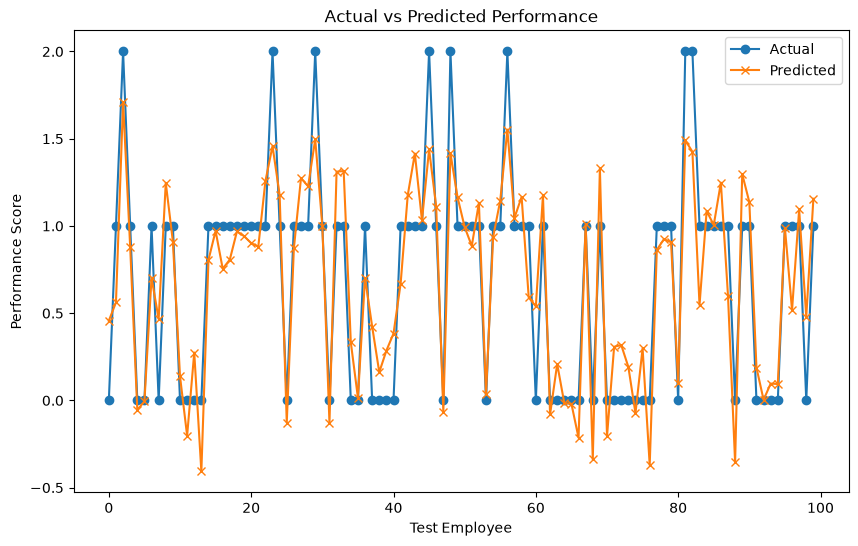

In [97]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score
# 1. Convert Performance into numbers
perf_map = {
    'Poor': 0,
    'Average': 1,
    'Good': 2
}

df['perf_num'] = df['Performance'].map(perf_map)

# 2. Select features
features = [
    'Age',
    'Experience_Years',
    'Hours_Worked_Per_Week',
    'Training_Score',
    'Job_Satisfaction',
    'Projects_Completed'
]
X = df[features]
y = df['perf_num']
# 3. Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)
# 4. Create Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)
# 5. Predict
y_pred = model.predict(X_test)
# 6. Convert predictions to categories
y_pred_class = y_pred.round().clip(0, 2)  #Keep values between 0 and 2. Anything below 0 becomes 0, and anything above 2 becomes 2.
# 7. Accuracy
accuracy = accuracy_score(y_test, y_pred_class)

print("Accuracy:", round(accuracy * 100, 2), "%")


# 8. MAE
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", round(mae, 2))


# 9. MSE
mse = mean_squared_error(y_test, y_pred)

print("MSE:", round(mse, 2))


# 10. R² Score
r2 = r2_score(y_test, y_pred)

print("R² Score:", round(r2, 2))


# 11. Actual vs Predicted graph
plt.figure(figsize=(10, 6))

plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(y_pred, label='Predicted', marker='x')

plt.title("Actual vs Predicted Performance")
plt.xlabel("Test Employee")
plt.ylabel("Performance Score")

plt.legend()
plt.show()